# Fig 3 — KS rejection-fraction for toy and astro models

Fraction of realizations with $p < 0.05$ as a function of source count $N_s$ and pulsar count $N_p$, for three populations (uniform and exponential toy amplitudes, and the astrophysical lown0 SMBHB model), with the data whitened with the response $R_{IJ}$. Two test variants:
- left column — KS with the *known scale* (or the realization-mean for the astro row). This is the idealized test that cannot be performed in reality.
- right column — KS with the scale estimated from the data and a bootstrap-calibrated null (Lilliefors-corrected).

The left column seems to react to sparse, non-Gaussian populations, i.e. rejection grows for fewer sources $N_s$ and more pulsars $N_p$ — but the right column shows this apparent sensitivity vanishes once the scale is estimated from the same realization: the whitened powers are Gaussian up to an unknown per-realization scale, so no non-Gaussian information survives.

## How to use this notebook
If you have downloaded this notebook from the repo set `REGENERATE_DATA = True` to recompute the data. It will be saved as `data/fig3_ks_rejection.npz`. Toy and astro data are stored separately so the slower astro data can be regenerated independently.

If you want to save the plot (it is saved under `plots/fig3_ks_rejection.pdf`), set `SAVE_PLOT` to True.

In [5]:
REGENERATE_DATA = False
SAVE_PLOT = True

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from helpers.pta_helpers import (
    run_toy_subset, run_astro_subset, set_paper_rcparams,
)

DATA_TOY = Path('data') / 'fig3_toy_ks_rejection.npz'
DATA_ASTRO = Path('data') / 'fig3_astro_ks_rejection.npz'
PLOT_PATH = Path('plots') / 'fig3_ks_rejection.pdf'
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
DATA_TOY.parent.mkdir(parents=True, exist_ok=True)

NPULSARS_LIST = [10, 20, 50, 67, 100, 200, 500]
NSOURCES_LIST = [1, 5, 10, 50, 100, 300, 500, 1000]
NREALIZATIONS = 5000
NSIDE = 16
FCENTER_TOY = np.array([1e-8])
N_BOOTSTRAP = 20000
SEED_TOY = 42
SEED_ASTRO = 123

## Compute or load the toy and astro sweeps

In [7]:
if REGENERATE_DATA or not DATA_TOY.exists():
    print('Running toy sweep ...')
    toy = run_toy_subset(
        npulsars_list=NPULSARS_LIST,
        nsources_list=NSOURCES_LIST,
        nrealizations=NREALIZATIONS,
        nside=NSIDE,
        fcenter=FCENTER_TOY,
        n_bootstrap=N_BOOTSTRAP,
        seed=SEED_TOY,
    )
    np.savez(DATA_TOY, **toy)
    print(f'Saved {DATA_TOY}')
else:
    toy = dict(np.load(DATA_TOY))
    print(f'Loaded {DATA_TOY}')

if REGENERATE_DATA or not DATA_ASTRO.exists():
    print('Running astro sweep (uses fastropop.SemiAnalyticPopulation) ...')
    astro = run_astro_subset(
        npulsars_list=NPULSARS_LIST,
        nsources_list=NSOURCES_LIST,
        nrealizations=NREALIZATIONS,
        nside=NSIDE,
        n_bootstrap=N_BOOTSTRAP,
        seed=SEED_ASTRO,
    )
    np.savez(DATA_ASTRO, **astro)
    print(f'Saved {DATA_ASTRO}')
else:
    astro = dict(np.load(DATA_ASTRO))
    print(f'Loaded {DATA_ASTRO}')

Loaded data/fig3_toy_ks_rejection.npz
Loaded data/fig3_astro_ks_rejection.npz


## Plot the 3 × 2 rejection grid

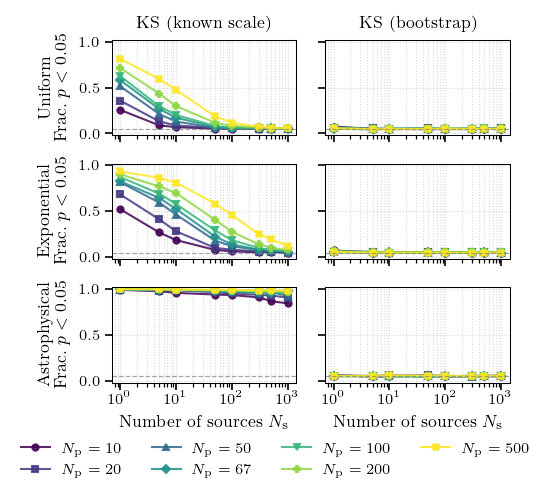

Saved plots/fig3_ks_rejection.pdf


In [8]:
use_tex, COLUMN_W, _ = set_paper_rcparams()

npulsars_list = list(np.asarray(toy['npulsars_list']).astype(int))
nsources_list = list(np.asarray(toy['nsources_list']).astype(int))
threshold = 0.05

cmap = plt.cm.viridis
colors_dict = {Np: cmap(i / max(len(npulsars_list) - 1, 1))
               for i, Np in enumerate(npulsars_list)}
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
marker_dict = {Np: markers[i % len(markers)]
               for i, Np in enumerate(npulsars_list)}

row_info = [
    ('Uniform',       toy['ks_naive_R_uniform'],     toy['ks_boot_R_uniform']),
    ('Exponential',   toy['ks_naive_R_exponential'], toy['ks_boot_R_exponential']),
    ('Astrophysical', astro['ks_naive_R_astro'],     astro['ks_boot_R_astro']),
]

fig, axes = plt.subplots(3, 2, figsize=(COLUMN_W, 3.2),
                         sharex=True, sharey='row')

for i_row, (label, naive_data, boot_data) in enumerate(row_info):
    ax_left = axes[i_row, 0]
    ax_right = axes[i_row, 1]
    for i_np, Np in enumerate(npulsars_list):
        color = colors_dict[Np]
        marker = marker_dict[Np]
        legend_label = r"$N_{\mathrm{p}}" + f"={Np}$"
        frac_naive = [np.mean(naive_data[i_np, i_ns] < threshold)
                      for i_ns in range(len(nsources_list))]
        frac_boot = [np.mean(boot_data[i_np, i_ns] < threshold)
                     for i_ns in range(len(nsources_list))]
        ax_left.plot(nsources_list, frac_naive, '-', marker=marker,
                     color=color, alpha=0.85, label=legend_label)
        ax_right.plot(nsources_list, frac_boot, '-', marker=marker,
                      color=color, alpha=0.85, label=legend_label)

    for ax in (ax_left, ax_right):
        ax.axhline(threshold, color='grey', linestyle='--', linewidth=0.6,
                   alpha=0.7)
        ax.set_xscale('log')
        ax.set_ylim(-0.02, 1.02)
        ax.tick_params(axis='both', which='major', pad=2)
        ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)

    if use_tex:
        ax_left.set_ylabel(label + '\nFrac.\\ $p < 0.05$')
    else:
        ax_left.set_ylabel(label + '\nFrac. p < 0.05')
    if i_row == 0:
        ax_left.set_title('KS (known scale)')
        ax_right.set_title('KS (bootstrap)')
    if i_row == 2:
        ax_left.set_xlabel(r'Number of sources $N_{\mathrm{s}}$')
        ax_right.set_xlabel(r'Number of sources $N_{\mathrm{s}}$')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=min(len(npulsars_list), 4),
           bbox_to_anchor=(0.5, -0.03), frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

if SAVE_PLOT:
    fig.savefig(PLOT_PATH)
    print(f'Saved {PLOT_PATH}')